## Metrics Evaluation Lab

Throughout your early career as a Data Scientist you've spent most your time cleaning data, but now you are starting to build models and have come to realize the most important part about understanding any machine learning model (or any model, really) is understanding its weakness and vulnerabilities.

In doing so you've decided to practice on a dataset about mushrooms, because after all if you don't know how to evaluate a model thoroughly you'll be in real **truffle** (ha...ha) and introduce a approach that is new to you. 

Below I've build an initial **Decision Tree** model on the mushroom dataset to get you started. Think of the Decision Tree as your field guide – splitting mushrooms into categories one feature at a time. 

### Part 1: Load and Clean

Using the [mushroom dataset](https://archive.ics.uci.edu/static/public/848/secondary+mushroom+dataset.zip) and the documentation below answer the provided question. 

- [Mushroom Documentation](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)

*How well can we predict whether a mushroom is poisonous or edible based on its physical characteristics?* 

### Part 2: Build the model

This will most be provided for you, but some details you'll need to code yourself. 

### Part 3: Evaluate and assess

Consider where classification errors are occurring, is there a pattern? If so discuss this pattern and why you think this is the case. Use the confusion matrix to determine the pattern. 

### Keys to Success

- Using the evaluation metrics correctly: we are focusing on classification not regression
- Evaluation is not about the metrics per se, but what they mean; speaking through your question in light of the evaluation metrics is the primary objective of this lab. Think of yourself as a "model detective" that works to leave no stone unturned!
- Remember, be patient and double check your code or you might find yourself in real **shiitake** :)

---
## Initial Decision Tree Model – Starter Code

The code below walks you through an initial Decision Tree classifier on the mushroom dataset. Use it as a *spore*-ing board (sorry, not sorry) to complete the lab.

### Step 1 – Imports

In [12]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import metrics

### Step 2 – Load the Mushroom Dataset

We load the mushroom dataset directly. The target column is `type` (poisonous **p** vs edible **e**). 

For the full lab you may want to use the secondary mushroom dataset from UCI:
- [Download](https://archive.ics.uci.edu/static/public/848/secondary+mushroom+dataset.zip)
- [Documentation](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)

In [13]:
# Load the mushroom dataset
mushroom_url = (
    "https://raw.githubusercontent.com/stedy/"
    "Machine-Learning-with-R-datasets/master/mushrooms.csv"
)

mushroom_data = pd.read_csv(mushroom_url)

print(f'Dataset shape: {mushroom_data.shape}')
mushroom_data.head()

Dataset shape: (8124, 23)


,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Step 3 – Explore the Data

In [14]:
# Use the various exploration methods we covered in class to understand the dataset.
mushroom_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   type                      8124 non-null   str  
 1   cap_shape                 8124 non-null   str  
 2   cap_surface               8124 non-null   str  
 3   cap_color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill_attachment           8124 non-null   str  
 7   gill_spacing              8124 non-null   str  
 8   gill_size                 8124 non-null   str  
 9   gill_color                8124 non-null   str  
 10  stalk_shape               8124 non-null   str  
 11  stalk_root                8124 non-null   str  
 12  stalk_surface_above_ring  8124 non-null   str  
 13  stalk_surface_below_ring  8124 non-null   str  
 14  stalk_color_above_ring    8124 non-null   str  
 15

In [15]:
mushroom_data.describe()

,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [16]:
# Check for missing values
mushroom_data.isna().sum()

type                        0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
dtype: int64

observations:
- all strings
- no missing
- some cols have more unuiqe values then others

### Step 4 – Clean & Prepare the Data



In [17]:
# Separate features (X) and target (y)
# Our target is 'type' – predicting poisonous (p) vs edible (e)
y = mushroom_data['type']
X = mushroom_data.drop('type', axis=1).copy()

In [18]:
# Calculate prevalence – how common is each class?
# This tells us what accuracy we'd get if we just guessed the majority class every time.
# If our model can't beat the prevalence, it's about as useful as a chocolate teapot...
# or a poisonous mushroom at a dinner party 
prevalence = y.value_counts(normalize=True)
prevalence


type
e    0.517971
p    0.482029
Name: proportion, dtype: float64

almost 50/50. this is good so that model doesnt get lazy if the porportion is to uneven.

### Collapse factor levels


Check for the levels of the categorical features
This helps us understand the diversity of our features and how they might influence the model 
and if we need to collapse rare categories to avoid overfitting on tiny groups of mushrooms, don't use 
a for loop, `nunique()` will give us the unique values for each column at once, its a function of the dataframe, 
not a function of the column, so we can call it on the whole dataframe and it will return the 
unique values for each column in one go


Then use data wrangler or another method to identify features that need to be collapsed, 
for example if a feature has 10 levels but 9 of them are very rare, 
we might want to collapse those 9 levels into an "other" 
category to avoid overfitting on those rare categories, this is especially 
important for decision trees which can easily overfit on rare categories

In [19]:
# Collapse rare categories in the 'habitat' feature
# This is a common preprocessing step to avoid overfitting on rare categories,
# especially important for decision trees which can easily overfit on rare categories
# X['habitat'] = X['habitat'].replace(['u', 'd'], 'other') # in this example we are simply replacing the 'u' and 'd' 
# categories with 'other', but in a real analysis we would want to look at the distribution of the categories and 
# decide which ones to collapse based on their frequency and importance to the model, 
# this is just an example to show how to do it, 
# you would need to adjust it based on your specific dataset and analysis needs

# Other functions that might be helpful for this step include value_counts(), where() and isin() 
# sample code for how that might look, but again you would need to adjust it based on your specific dataset and analysis needs

#top_cats = df['col'].value_counts().nlargest(2).index # this would give us the top 2 most common categories in the 'col' feature,
#df['new_col'] = df['col'].where(df['col'].isin(top_cats), 'Other') # this would create a new column 'new_col' where the 
# values are the same as 'col' for the top 2 categories,and 'Other' for all other categories,
# this is a common way to collapse rare categories into an 'Other' category,
# but again you would need to adjust it based on your specific dataset and analysis needs.

In [20]:
X.nunique()
# see count of each cols unquie values

cap_shape                    6
cap_surface                  4
cap_color                   10
bruises                      2
odor                         9
gill_attachment              2
gill_spacing                 2
gill_size                    2
gill_color                  12
stalk_shape                  2
stalk_root                   5
stalk_surface_above_ring     4
stalk_surface_below_ring     4
stalk_color_above_ring       9
stalk_color_below_ring       9
veil_type                    1
veil_color                   4
ring_number                  3
ring_type                    5
spore_print_color            9
population                   6
habitat                      7
dtype: int64

In [21]:
# see all the different values in each col, but not showing the distributions through % but in counts
print(X['cap_shape'].value_counts())
print(X['cap_color'].value_counts())
print(X['odor'].value_counts())
print(X['gill_color'].value_counts())
print(X['stalk_root'].value_counts())
print(X['stalk_surface_above_ring'].value_counts())
print(X['stalk_surface_below_ring'].value_counts())
print(X['stalk_color_above_ring'].value_counts())
print(X['stalk_color_below_ring'].value_counts())
print(X['veil_color'].value_counts())
print(X['ring_number'].value_counts())
print(X['ring_type'].value_counts())
print(X['spore_print_color'].value_counts())
print(X['population'].value_counts())
print(X['habitat'].value_counts())

cap_shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64
cap_color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64
odor
n    3528
f    2160
y     576
s     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
gill_color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64
stalk_root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64
stalk_surface_above_ring
s    5176
k    2372
f     552
y      24
Name: count, dtype: int64
stalk_surface_below_ring
s    4936
k    2304
f     600
y     284
Name: count, dtype: int64
stalk_color_above_ring
w    4464
p    1872
g     576
n     448
b     432
o     192
e      96
c      36
y       8
Name: count, dtype: int64
stalk_color_below_ring
w    4384
p    1872
g     576
n     512
b     432
o     192

looking at the above and the data wrangler and choose variables to collapse given that one or two distinct characters make up most of the data and there are many smaller weighted ones which can be grouped into an other category:
- cap_shape
    - keep: x and f
- cap_color
    - keep: n, g, and e
- odor
    - keep: n and f
- gill_color
    - keep: b, p, and w
- stalk_root
    - keep: b
    - there were a lot of '?' so just combing all of it into an other 
- stalk_surface_above_ring
    - keep: s
- stalk_surface_below_ring
    - keep: s
- stalk_color_above_ring
    - keep: w
- stalk_color_below_ring
    - keep: w
- veil_color
    - keep: w
- ring_number
    - keep: o
- ring_type
    - keep: p and e
- spore_print_color
    - keep: w, n, k
- population
    - keep: v
- habitat
    - keep: d and g

In [22]:
# following my observations above, manually replace the small % variables to make more even splits and replace with bigger other category.
X['cap_shape'] = X['cap_shape'].replace(['k', 'b', 's', 'c'], 'other')
X['cap_color'] = X['cap_color'].replace(['y', 'w', 'b', 'p', 'c', 'u', 'r'], 'other')
X['odor'] = X['odor'].replace(['y', 's', 'a', 'l', 'p', 'c', 'm'], 'other')
X['gill_color'] = X['gill_color'].replace(['n', 'g', 'h', 'u', 'k', 'e', 'y', 'o', 'r'], 'other')
X['stalk_root'] = X['stalk_root'].replace(['?', 'e', 'c', 'r'], 'other')
X['stalk_surface_above_ring'] = X['stalk_surface_above_ring'].replace(['k', 'f', 'y'], 'other')
X['stalk_surface_below_ring'] = X['stalk_surface_below_ring'].replace(['k', 'f', 'y'], 'other')
X['stalk_color_above_ring'] = X['stalk_color_above_ring'].replace(['p', 'g', 'n', 'b', 'o', 'e', 'c', 'y'], 'other')
X['stalk_color_below_ring'] = X['stalk_color_below_ring'].replace(['p', 'g', 'n', 'b', 'o', 'e', 'c', 'y'], 'other')
X['veil_color'] = X['veil_color'].replace(['n', 'o', 'y'], 'other')
X['ring_number'] = X['ring_number'].replace(['t', 'n'], 'other')
X['ring_type'] = X['ring_type'].replace(['l', 'f', 'n'], 'other')
X['spore_print_color'] = X['spore_print_color'].replace(['h', 'r', 'u', 'o', 'y', 'b'], 'other')
X['population'] = X['population'].replace(['y', 's', 'n', 'a', 'c'], 'other')
X['habitat'] = X['habitat'].replace(['p', 'l', 'u', 'm', 'w'], 'other')

In [23]:
#check the unuqie values again to make sure the replacements worked
X.nunique()

cap_shape                   3
cap_surface                 4
cap_color                   4
bruises                     2
odor                        3
gill_attachment             2
gill_spacing                2
gill_size                   2
gill_color                  4
stalk_shape                 2
stalk_root                  2
stalk_surface_above_ring    2
stalk_surface_below_ring    2
stalk_color_above_ring      2
stalk_color_below_ring      2
veil_type                   1
veil_color                  2
ring_number                 2
ring_type                   3
spore_print_color           4
population                  2
habitat                     3
dtype: int64

good this now has a lot more 50/50 even distibutions instead of bunch of smaller mosre spesific unquie values that could make the desicon tree overfit

### Step 5 – Partition the Data

We split our fungi into training, tuning, and test sets.

In [24]:
# 70 / 15 / 15 split – train / tune / test
# Stratify keeps the same ratio of edible:poisonous in each set, which is important for evaluation.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.70, stratify=y, random_state=21) #70/30
X_tune, X_test, y_tune, y_test = train_test_split(X_temp, y_temp, train_size=0.50, stratify=y_temp, random_state=21) # 15/15 of the 30

In [25]:
categorical_features = X.select_dtypes(include='object').columns.tolist() # creating a list of the categorical features, 
# this will be used later for preprocessing in the pipeline, in this example we are using a ordinal encoder 
# which can handle categorical features without needing to one-hot encode them,
# but we need to tell the pipeline which features are categorical so it knows to apply the ordinal encoder to 
# those features and not to the numeric features (if we had any).


# Create a LabelEncoder for the target variable
le_target = LabelEncoder()
le_target.fit(y)

# Build decision tree pipeline with OrdinalEncoder preprocessing
dt_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer( #note the preprocessor and the classifier on the same level of the pipeline, 
        #this is important because we want to make sure that the preprocessing is applied to the 
        # training data during cross-validation and grid search, if we put the preprocessor inside the classifier 
        # it would only be applied to the test data and not the training data, which would lead to data leakage and overfitting
        transformers=[
            ('ordinal', OrdinalEncoder(), categorical_features) # applying the ordinal encoder to the categorical features, 
            #this will convert the categorical features into numeric 
            # values that can be used by the decision tree classifier
        ],
        remainder='passthrough'
    )),
    ('classifier', DecisionTreeClassifier(random_state=42, criterion='gini'))
])

# Evaluate with 5-fold cross-validation on training data
cv_scores = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


# Fit final model on full training data
dt_pipeline.fit(X_train, y_train)

train_accuracy = dt_pipeline.score(X_train, y_train)
print(f"Pipeline Training accuracy:{train_accuracy}")
print(f"Pipeline Tuning accuracy:{cv_scores.mean()}")

/tmp/ipykernel_23238/2110220016.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include='object').columns.tolist() # creating a list of the categorical features,


Pipeline Training accuracy:1.0
Pipeline Tuning accuracy:1.0


So this is good, but maybe honestly too good. It seems like this is major major overfitting and that it is able to perfectly predict but how do we know its not just memorizing and able to give these perfect choosings based on the testing/tuning and would it be able to perform on other random new testing data?

---
## Evaluation Metrics

Time to find out how well our tree knows its fungi.

In [26]:
# Generate predictions and predicted probabilities on the tuning set and pass into variables
# Think of probabilities as how confident our tree is, example below
dt_pred = dt_pipeline.predict(X_tune)
dt_prob = dt_pipeline.predict_proba(X_tune)

# Bundle everything into a tidy DataFrame
results = pd.DataFrame({
    'target': y_tune,
    'pred': dt_pred,
    'prob_edible': dt_prob[:, 0], # first column
    'prob_poisonous': dt_prob[:, 1] # second column
})

#### Confusion Matrix

The confusion matrix shows us where our model is getting confused, build a confusion matrix and see how the model is performing. Give a 2 sentence summary on what you see. 

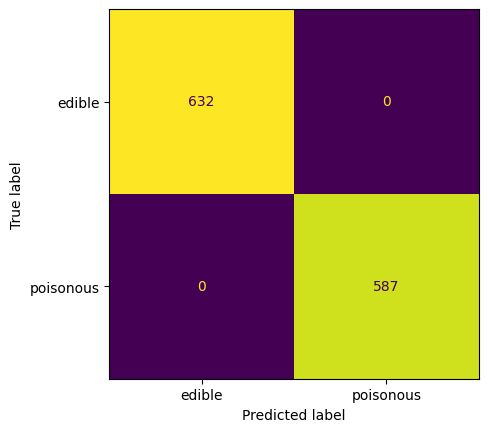

In [27]:
metrics.ConfusionMatrixDisplay.from_predictions(results.target, results.pred, display_labels=['edible', 'poisonous'], colorbar=False)

the confusion matrix shows the model perfectly classified every mushroom in the tune set with 632 edible and 587 poisonous with zero errors in either direction. while this looks great on the surface, a perfect confusion matrix is a red flag for overfitting, meaning the model likely memorized the training data rather than learning patterns that generalize to new mushrooms.

#### True Positive Rate (Sensitivity / Recall) & False Positive Rate

In [28]:
# TPR (True Positive Rate) = Recall = Sensitivity
# Of all the actually poisonous mushrooms, how many did we correctly flag?
# FPR (False Positive Rate) = how many safe mushrooms did we wrongly accuse?

tn, fp, fn, tp = metrics.confusion_matrix(results.target, results.pred, labels=['e', 'p']).ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print(f"TPR (Sensitivity/Recall): {tpr:.4f}")
print(f"FPR (False Positive Rate): {fpr:.4f}")

TPR (Sensitivity/Recall): 1.0000
FPR (False Positive Rate): 0.0000


a TPR of 1.0 means the model caught 100% of poisonous mushrooms, and an FPR of 0.0 means it never falsely accused a safe mushroom. in a real mushroom classification scenario, TPR is more important because a missed poisonous mushroom is more dangerous than a false alarm. these perfect scores again point to overfitting.

#### Classification Report

In [29]:
# Full classification report – the tasting menu of evaluation metrics 
print(metrics.classification_report(results.target, results.pred))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       632
           p       1.00      1.00      1.00       587

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



#### ROC Curve & AUC

The ROC curve plots TPR vs FPR at every threshold. AUC (Area Under the Curve) summarises it in one number – 1.0 is perfect, 0.5 is a coin flip.  

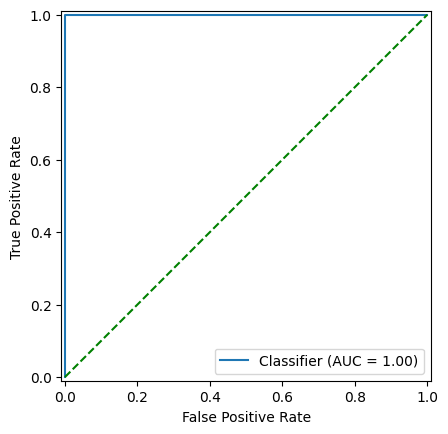

Final Model AUC: 1.0


In [ ]:
metrics.RocCurveDisplay.from_predictions(results.target, results.prob_poisonous, pos_label='p') # pos_label is saying look at poisonous as the positive class
plt.plot([0, 1], [0, 1], 'g--') #green with dashes
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

print(f"Final Model AUC: {metrics.roc_auc_score(results.target == 'p', #saying look at poisonous as the positive class
                                                results.prob_poisonous)}")

### Write a summary of what you found based on the evaluation measures. Include where have you noticed some issues with the model and What metrics do you think we should pay most attention to given the target variable.

 - Do you think we should adjust the threshold from the default value or not? Why or why not?

all the metrics like the confusion matrix, TPR, classification report, ROC curve, AUC all came back a perfect 1.0, which honestly sounds great but is actually a red flag. the decision tree basically memorized the training data instead of learning patterns that would hold up on new mushrooms. the dataset also just happens to be really clean so maybe its just that was almost too easy for the tree to overfit. given whats actually trying to be predicted here is whether a mushroom is poisonous or not then i think TPR is the metric i'd care most about because a false negative means someone actually eats a poisonous mushroom, which is obviously way worse than a false positive where you just throw out a safe one. so even if TPR came at the cost of a higher FPR then that tradeoff is worth it. For the threshold I think there's no reason to adjust it here since everything is already perfect but in a messier maybe more real world realistic dataset then i'd lower it to below 0.5 for the poisonous class so thats basically making the model more prone about flagging things as poisonous. even though you'd get more false alarms but you'd also catch more actual poisonous mushrooms, and that's the whole point and better outcome anyway.

---

You now have a working Decision Tree baseline.

**Attempt the Bonus** 5 points each:

Pick a metric we haven’t covered (e.g., Matthews Correlation Coefficient, Precision-Recall AUC, Cohen’s Kappa) and discuss it.

Choose a model we have not present in class and see if the evaluation is better or worse - be specific about the metric you are using for comparison and why the model seems to fit better or worse. 



In [31]:
# MCC

from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(results.target, results.pred)
print(f"Matthews Correlation Coefficient: {mcc}")

Matthews Correlation Coefficient: 1.0


the MCC is a metric that measures the quality of a classification model by taking into account all four boxes of the confusion matrix and what makes it useful compared to regular accuracy is that it works well even when the classes are imbalanced. it outputs a value between -1 and 1, where 1 is a perfect model, 0 is basically a coin flip, and -1 means the model is getting everything wrong. this MCC came back 1.0 which lines up with all the other perfect scores, but in a messier dataset with imbalanced classes this would be a more trustworthy metric than accuracy alone since accuracy can be misleading when one class shows up way more than the other.